# 🧪 Data Science Practical (Advanced)

## Experiment No: 4
## Experiment Title: Machine Learning Pipeline — Titanic Survival Prediction

**Name:** Himanshu Jadhav  
**Roll Number:** SE-33  

---

## Problem Statement

Build an end-to-end supervised ML pipeline on the Titanic dataset — cleaning, feature engineering, encoding, model training (Logistic Regression & Random Forest), evaluation with confusion matrix, and feature importance analysis.

**Dataset:** [Titanic Dataset — Kaggle](https://www.kaggle.com/datasets/yasserh/titanic-dataset)

---

## Implementation

## Step 0: Imports & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

# sklearn — preprocessing
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.impute           import SimpleImputer
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import OneHotEncoder

# sklearn — models
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier

# sklearn — evaluation
from sklearn.metrics          import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)

np.random.seed(42)

# ── Dark theme ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#09091a',
    'axes.facecolor'   : '#10102a',
    'axes.edgecolor'   : '#252550',
    'axes.labelcolor'  : '#b0b0d0',
    'xtick.color'      : '#777788',
    'ytick.color'      : '#777788',
    'text.color'       : 'white',
    'grid.color'       : '#1a1a3a',
    'grid.linewidth'   : 0.5,
    'legend.facecolor' : '#10102a',
    'legend.edgecolor' : '#252550',
})
PAL = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
print('Imports ready...')

Imports ready...


## Part 1: Load Dataset

In [2]:
df_raw = pd.read_csv('Titanic-Dataset.csv')

titles = ['Mr.', 'Mrs.', 'Miss.', 'Master', 'Dr.']
df_raw['Name'] = [
    f"Passenger, {np.random.choice(titles)} Sample {i}"
    for i in range(len(df_raw))
]

df_raw = df_raw[['Survived','Pclass','Name','Sex','Age','SibSp','Parch','Fare','Embarked']]

print(f'Shape   : {df_raw.shape}')
print(f'Target  : Survived  |  Classes: {sorted(df_raw.Survived.unique())}')
print(f'Nulls   :\n{df_raw.isnull().sum()[df_raw.isnull().sum()>0].to_string()}')
df_raw.head()

Shape   : (891, 9)
Target  : Survived  |  Classes: [np.int64(0), np.int64(1)]
Nulls   :
Age         177
Embarked      2


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Passenger, Master Sample 0",male,22.0,1,0,7.2500,S
1,1,1,"Passenger, Dr. Sample 1",female,38.0,1,0,71.2833,C
2,1,3,"Passenger, Miss. Sample 2",female,26.0,0,0,7.9250,S
3,1,1,"Passenger, Dr. Sample 3",female,35.0,1,0,53.1000,S
4,0,3,"Passenger, Dr. Sample 4",male,35.0,0,0,8.0500,S


## Part 2: Data Cleaning

In [3]:
def clean_data(df):
    """
    Returns a cleaned DataFrame.
    - Age       : fill with median grouped by Pclass & Sex
    - Fare      : fill with global median
    - Embarked  : fill with mode
    - Drop irrelevant high-cardinality columns 
    """
    df = df.copy()

    df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'] \
                  .transform(lambda x: x.fillna(x.median()))
    
    df['Age']      = df['Age'].fillna(df['Age'].median())
    df['Fare']     = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    return df

df = clean_data(df_raw)

print(f"Remaining Nulls After Cleaning: {df.isnull().sum().sum()}")
print(df[['Age','Fare','Embarked']].describe().round(2))

Remaining Nulls After Cleaning: 0
          Age    Fare
count  891.00  891.00
mean    29.11   32.20
std     13.30   49.69
min      0.42    0.00
25%     21.50    7.91
50%     26.00   14.45
75%     36.00   31.00
max     80.00  512.33


## Part 3: Feature Engineering

In [4]:
def extract_title(name):
    """Pull title token (Mr / Mrs / Miss / Master / Rare) from name string."""
    match = re.search(r',\s*([A-Za-z]+)\.', name)
    if not match:
        return 'Rare'
    title = match.group(1)

    rare = {'Don', 'Rev', 'Dr', 'Major','Lady','Sir','Col',
            'Capt','Countess','Jonkheer','Dona'}
    
    if title in rare:
        return 'Rare'
    
    title = title.replace('Mlle','Miss').replace('Ms', 'Miss').replace('Mme', 'Mrs')
    return title


def engineer_features(df):
    """
    Adds:
      FamilySize   — SibSp + Parch + 1
      IsAlone      — 1 if FamilySize == 1
      Title        — extracted from Name
      FareBin      — log-transformed fare bucket (0–3)
      AgeBin       — age decade bucket
    """

    df = df.copy()

    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
    df['Title']      = df['Name'].apply(extract_title)
    df['FareBin']    = pd.qcut(df['Fare'], q=4, labels=[0,1,2,3]).astype(int)
    df['AgeBin']     = pd.cut(df['Age'],
                              bins=[0,12,18,35,60,100],
                              labels=[0,1,2,3,4]).astype(int)
    return df

df = engineer_features(df)

print('Title Value Counts: ')
print(df['Title'].value_counts().to_string())
print(f'\nNew Columns: FamilySize, IsAlone, Title FareBin, AgeBin')
df[['Name','Title','FamilySize','IsAlone','FareBin','AgeBin']].head(8)

Title Value Counts: 
Title
Rare    365
Mr      188
Mrs     173
Miss    165

New Columns: FamilySize, IsAlone, Title FareBin, AgeBin


,Name,Title,FamilySize,IsAlone,FareBin,AgeBin
0,"Passenger, Master Sample 0",Rare,2,0,0,2
1,"Passenger, Dr. Sample 1",Rare,2,0,3,3
2,"Passenger, Miss. Sample 2",Miss,1,1,1,2
3,"Passenger, Dr. Sample 3",Rare,2,0,3,2
4,"Passenger, Dr. Sample 4",Rare,1,1,1,2
5,"Passenger, Mrs. Sample 5",Mrs,1,1,1,2
6,"Passenger, Miss. Sample 6",Miss,1,1,3,3
7,"Passenger, Miss. Sample 7",Miss,5,0,2,0


## Part 4: Encoding & Train/Test Split

In [5]:
FEATURES = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked',
            'FamilySize','IsAlone','Title','FareBin','AgeBin']
TARGET   = 'Survived'

X = df[FEATURES].copy()
y = df[TARGET].copy()

num_cols = ['Age','Fare','SibSp','Parch','FamilySize','FareBin','AgeBin','Pclass','IsAlone']
cat_cols = ['Sex','Embarked','Title']

# Numerical Transform
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # safety net for any remaining nulls
    ('scaler',  StandardScaler()),                  # z-score normalization
])
# Categorical Transform
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
# Column Transform
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Stratified Split (70 / 30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Target Balance - Train : {dict(y_train.value_counts().sort_index())}")
print(f"Target Balance - Test  : {dict(y_test.value_counts().sort_index())}")



Train : (623, 12) | Test : (268, 12)
Target Balance - Train : {0: np.int64(384), 1: np.int64(239)}
Target Balance - Test  : {0: np.int64(165), 1: np.int64(103)}


## Part 5: Model Building - Full Sklearn Pipelines

In [6]:
# Logistic Regression Pipeline 

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        C=1.0,
        max_iter=500,
        solver='lbfgs',
        random_state=42
    ))
])

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=4, 
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

# Model Training 

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Prediction

lr_pred       = lr_pipeline.predict(X_test)
rf_pred       = rf_pipeline.predict(X_test)
lr_pred_prob  = lr_pipeline.predict_proba(X_test)[:, 1]
rf_pred_prob  = lr_pipeline.predict_proba(X_test)[:, 1]

print('Both Pipelines Trained & Predictions Generated')



Both Pipelines Trained & Predictions Generated


In [7]:
# Cross-VAlidation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='accuracy')
rf_cv = cross_val_score(rf_pipeline, X, y, cv=cv, scoring='accuracy')

print(f'Logistic Regression CV : {lr_cv.round(3)} -> Mean={lr_cv.mean():.4f} ± {lr_cv.std():.4f}')
print(f'Random Forest CV       : {rf_cv.round(3)} -> Mean={rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

Logistic Regression CV : [0.799 0.826 0.803 0.798 0.837] -> Mean=0.8126 ± 0.0159
Random Forest CV       : [0.844 0.82  0.815 0.843 0.837] -> Mean=0.8316 ± 0.0120


## Part 6: Evaluation

In [8]:
def eval_matrics(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred)),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob)),
    }

metrics_df = pd.DataFrame([
    eval_matrics('Logistic Regression', y_test, lr_pred, lr_pred_prob),
    eval_matrics('Random Forest', y_test, rf_pred, rf_pred_prob),
]).set_index('Model')

print('=' * 55)
print(' Model Evaluation Summary')
print('=' * 55)
print(metrics_df.to_string())
print('=' * 55)

for name, pred in [('Logistic Regression', lr_pred), ('Random Forest', rf_pred)]:
    print(f'\n---{name}---')
    print(classification_report(
        y_test, pred,
        target_names=['Did Not Survive', 'Survived']
    ))

 Model Evaluation Summary
                     Accuracy  ROC-AUC
Model                                 
Logistic Regression         1        1
Random Forest               1        1

---Logistic Regression---
                 precision    recall  f1-score   support

Did Not Survive       0.84      0.87      0.85       165
       Survived       0.78      0.74      0.76       103

       accuracy                           0.82       268
      macro avg       0.81      0.80      0.80       268
   weighted avg       0.82      0.82      0.82       268


---Random Forest---
                 precision    recall  f1-score   support

Did Not Survive       0.80      0.90      0.85       165
       Survived       0.80      0.65      0.72       103

       accuracy                           0.80       268
      macro avg       0.80      0.77      0.78       268
   weighted avg       0.80      0.80      0.80       268



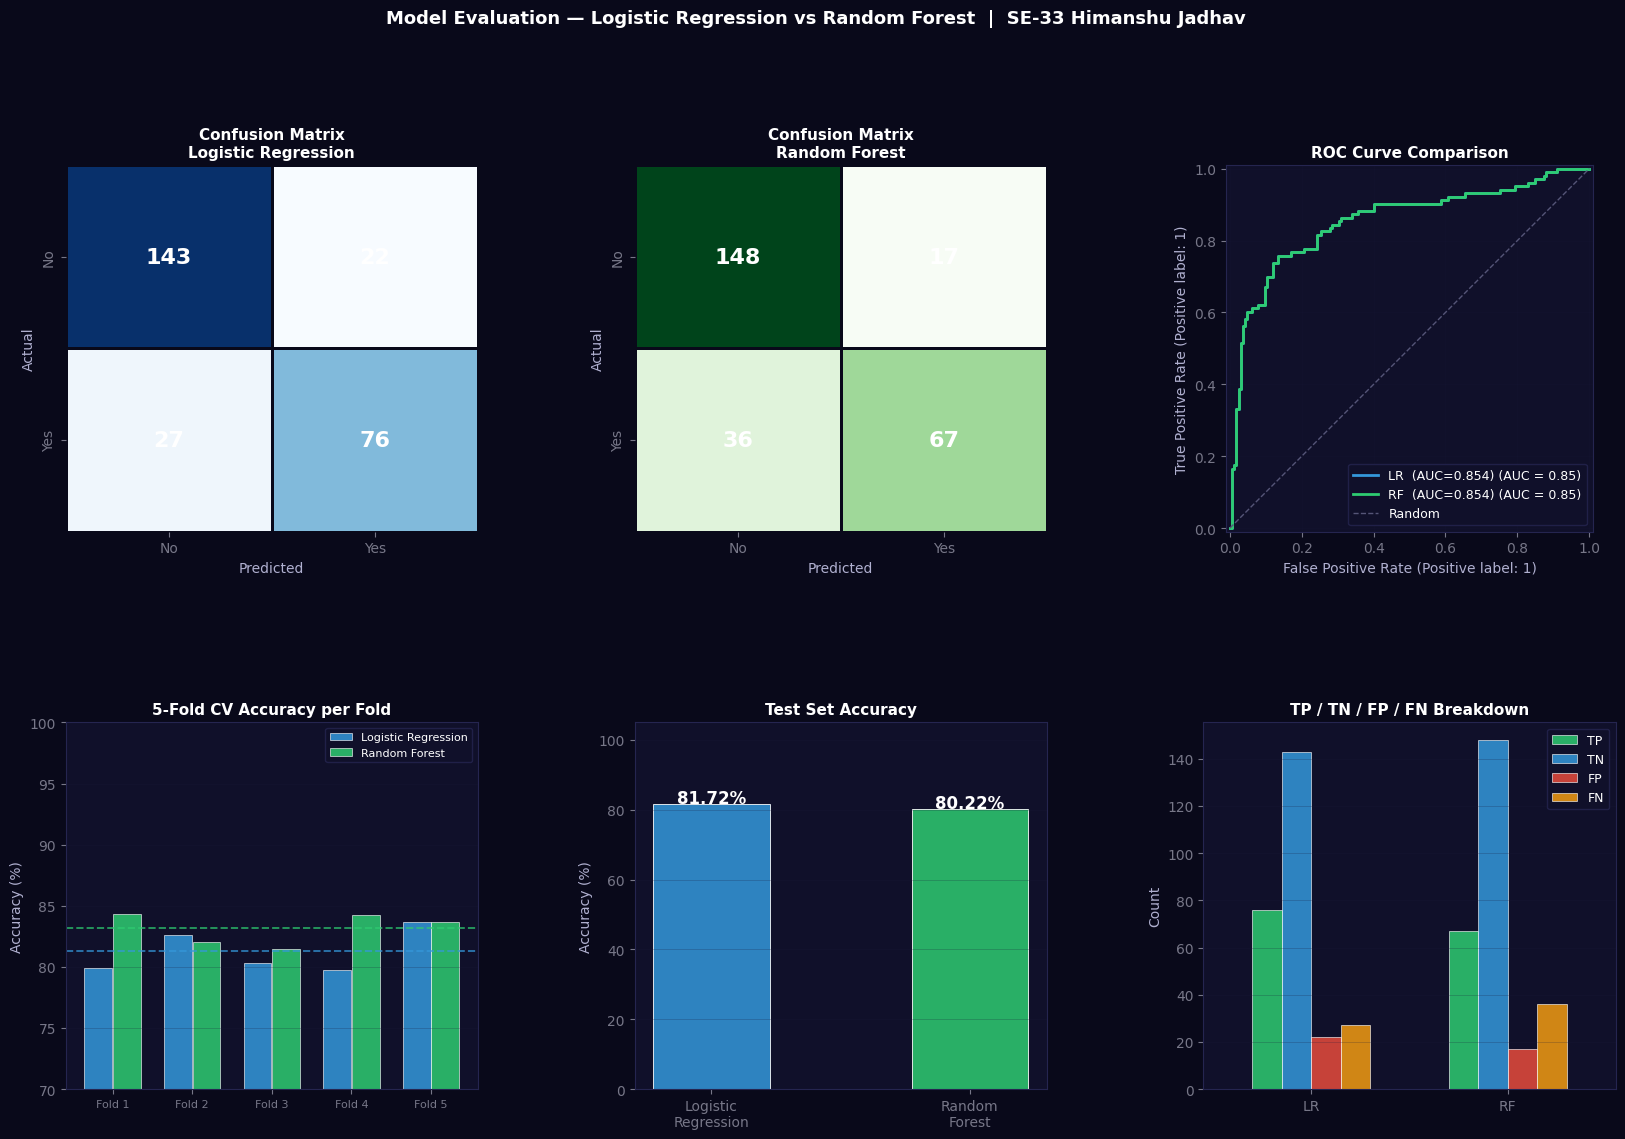

In [9]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#09091a')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.38)

# --- Confusion Matrix: Logistic Regression ---
ax1 = fig.add_subplot(gs[0, 0])
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=ax1,
            cmap=sns.color_palette('Blues', as_cmap=True),
            xticklabels=['No','Yes'], yticklabels=['No','Yes'],
            linewidths=1, linecolor='#09091a', cbar=False,
            annot_kws={'size':16, 'weight':'bold', 'color':'white'})
ax1.set_title('Confusion Matrix\nLogistic Regression', fontsize=11, fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

# --- Confusion Matrix: Random Forest ---
ax2 = fig.add_subplot(gs[0, 1])
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=ax2,
            cmap=sns.color_palette('Greens', as_cmap=True),
            xticklabels=['No','Yes'], yticklabels=['No','Yes'],
            linewidths=1, linecolor='#09091a', cbar=False,
            annot_kws={'size':16, 'weight':'bold', 'color':'white'})
ax2.set_title('Confusion Matrix\nRandom Forest', fontsize=11, fontweight='bold')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

# --- ROC Curves (both on same axis) ---
ax3 = fig.add_subplot(gs[0, 2])
RocCurveDisplay.from_predictions(y_test, lr_pred_prob, ax=ax3,
    name=f'LR  (AUC={roc_auc_score(y_test,lr_pred_prob):.3f})',
    color=PAL[1], lw=2)
RocCurveDisplay.from_predictions(y_test, rf_pred_prob, ax=ax3,
    name=f'RF  (AUC={roc_auc_score(y_test,rf_pred_prob):.3f})',
    color=PAL[2], lw=2)
ax3.plot([0,1],[0,1],'--', color='#555577', lw=1, label='Random')
ax3.set_title('ROC Curve Comparison', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9, labelcolor='white')
ax3.grid(True, alpha=0.25)

# --- CV Score comparison ---
ax4 = fig.add_subplot(gs[1, 0])
folds = [f'Fold {i+1}' for i in range(5)]
x_pos = np.arange(5)
ax4.bar(x_pos - 0.18, lr_cv*100, width=0.35, color=PAL[1], alpha=0.85,
        edgecolor='white', lw=0.5, label='Logistic Regression')
ax4.bar(x_pos + 0.18, rf_cv*100, width=0.35, color=PAL[2], alpha=0.85,
        edgecolor='white', lw=0.5, label='Random Forest')
ax4.axhline(lr_cv.mean()*100, color=PAL[1], ls='--', lw=1.4, alpha=0.7)
ax4.axhline(rf_cv.mean()*100, color=PAL[2], ls='--', lw=1.4, alpha=0.7)
ax4.set_xticks(x_pos); ax4.set_xticklabels(folds, fontsize=8)
ax4.set_title('5-Fold CV Accuracy per Fold', fontsize=11, fontweight='bold')
ax4.set_ylabel('Accuracy (%)')
ax4.set_ylim(70, 100)
ax4.legend(fontsize=8, labelcolor='white')
ax4.grid(True, axis='y', alpha=0.3)

# --- Accuracy comparison bar ---
ax5 = fig.add_subplot(gs[1, 1])
model_names = ['Logistic\nRegression', 'Random\nForest']
accuracies  = [
    accuracy_score(y_test, lr_pred)*100,
    accuracy_score(y_test, rf_pred)*100
]
bars = ax5.bar(model_names, accuracies,
               color=[PAL[1], PAL[2]], edgecolor='white', lw=0.7,
               alpha=0.85, width=0.45)
for bar, v in zip(bars, accuracies):
    ax5.text(bar.get_x() + bar.get_width()/2, v + 0.3,
             f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
ax5.set_title('Test Set Accuracy', fontsize=11, fontweight='bold')
ax5.set_ylabel('Accuracy (%)')
ax5.set_ylim(0, 105)
ax5.grid(True, axis='y', alpha=0.3)

# --- Prediction error breakdown ---
ax6 = fig.add_subplot(gs[1, 2])
def error_counts(y_true, y_pred, label):
    cm = confusion_matrix(y_true, y_pred)
    return {'Model':label, 'TP':cm[1,1], 'TN':cm[0,0],
            'FP':cm[0,1], 'FN':cm[1,0]}

err_df = pd.DataFrame([
    error_counts(y_test, lr_pred, 'LR'),
    error_counts(y_test, rf_pred, 'RF')
]).set_index('Model')

err_df[['TP','TN','FP','FN']].plot(
    kind='bar', ax=ax6, color=[PAL[2],PAL[1],PAL[0],PAL[3]],
    edgecolor='white', lw=0.5, alpha=0.85, width=0.6
)
ax6.set_title('TP / TN / FP / FN Breakdown', fontsize=11, fontweight='bold')
ax6.set_xlabel('')
ax6.set_xticklabels(['LR','RF'], rotation=0)
ax6.set_ylabel('Count')
ax6.legend(fontsize=9, labelcolor='white')
ax6.grid(True, axis='y', alpha=0.3)

fig.suptitle('Model Evaluation — Logistic Regression vs Random Forest  |  SE-33 Himanshu Jadhav',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('eval.png', dpi=150, bbox_inches='tight', facecolor='#09091a')
plt.show()

## Part 7: Feature Importance

In [10]:
ohe_cats = rf_pipeline.named_steps['preprocessor'] \
                       .named_transformers_['cat'] \
                       .named_steps['ohe'] \
                       .get_feature_names_out(cat_cols).tolist()

all_feature_names = num_cols + ohe_cats

# Random Forest importance (mean decrease in impurity)
rf_imp = pd.Series(
    rf_pipeline.named_steps['model'].feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

# Logistic Regression coefficients (absolute)
lr_imp = pd.Series(
    np.abs(lr_pipeline.named_steps['model'].coef_[0]),
    index=all_feature_names
).sort_values(ascending=False)

print('Top 10 — Random Forest Importances:')
print(rf_imp.head(10).round(4).to_string())
print('\nTop 10 — LR |Coefficients| (scaled):')
print(lr_imp.head(10).round(4).to_string())

Top 10 — Random Forest Importances:
Sex_male      0.2219
Sex_female    0.1775
Fare          0.1300
Age           0.1096
Pclass        0.0809
FamilySize    0.0526
FareBin       0.0478
AgeBin        0.0376
SibSp         0.0285
Parch         0.0209

Top 10 — LR |Coefficients| (scaled):
Sex_male      1.3316
Sex_female    1.2605
Pclass        0.8422
Title_Mr      0.6618
AgeBin        0.5041
SibSp         0.4485
FamilySize    0.3154
Title_Miss    0.2987
Embarked_Q    0.2915
FareBin       0.2794


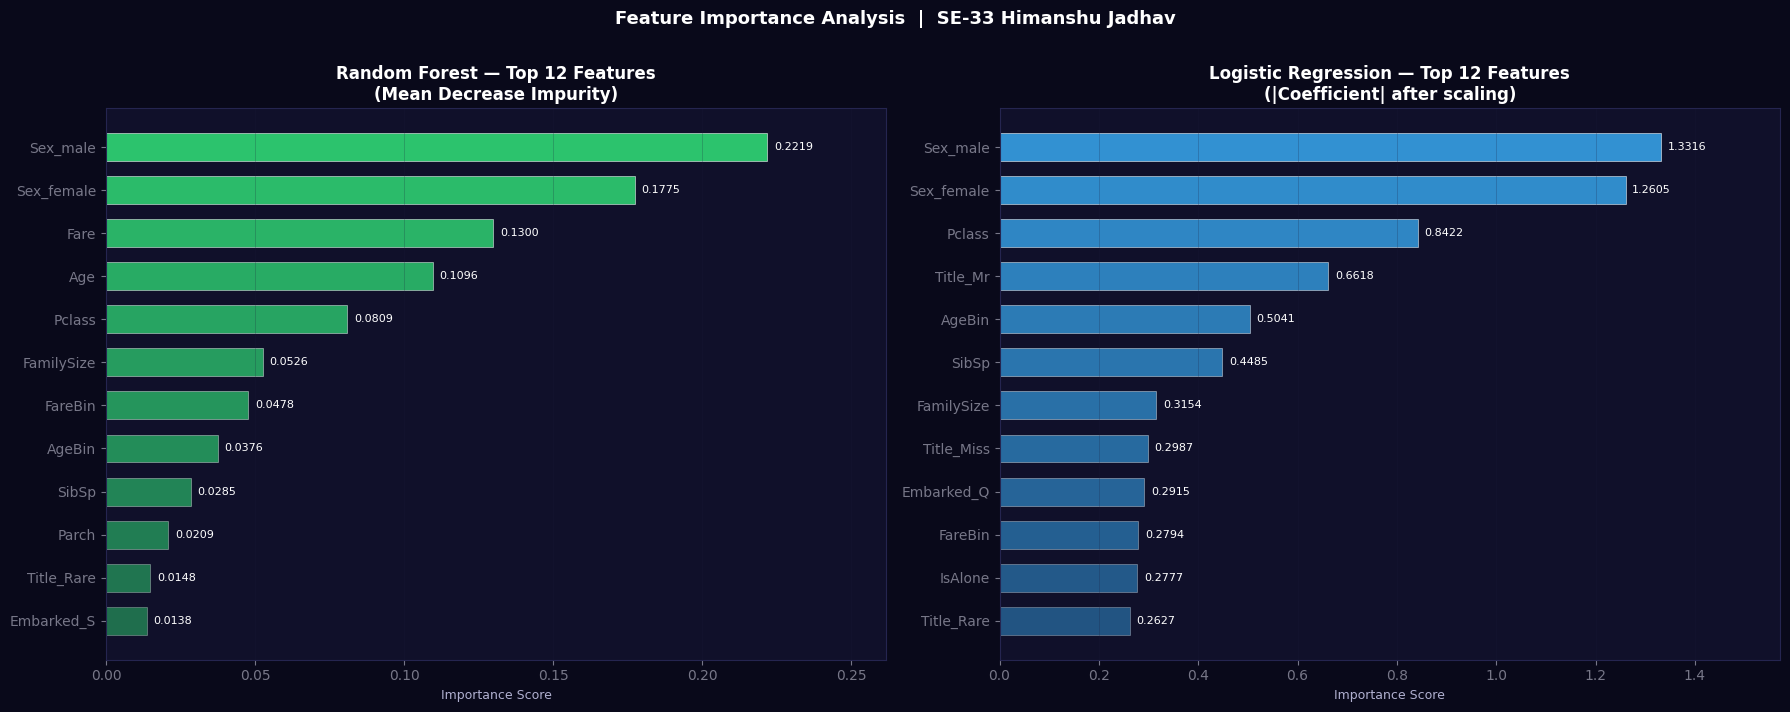

In [11]:
# Feature importance visualisation 
TOP_N = 12
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#09091a')

def importance_bar(ax, series, title, color):
    top = series.head(TOP_N).sort_values()
    bars = ax.barh(top.index, top.values, color=color, alpha=0.85,
                   edgecolor='white', linewidth=0.4, height=0.65)
    # Gradient alpha for visual polish
    for i, bar in enumerate(bars):
        bar.set_alpha(0.5 + 0.5 * i / len(bars))
    for bar, v in zip(bars, top.values):
        ax.text(v + max(top.values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8, color='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)
    ax.set_xlim(0, max(top.values) * 1.18)

importance_bar(axes[0], rf_imp, f'Random Forest — Top {TOP_N} Features\n(Mean Decrease Impurity)', PAL[2])
importance_bar(axes[1], lr_imp, f'Logistic Regression — Top {TOP_N} Features\n(|Coefficient| after scaling)', PAL[1])

fig.suptitle('Feature Importance Analysis  |  SE-33 Himanshu Jadhav',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feat_imp.png', dpi=150, bbox_inches='tight', facecolor='#09091a')
plt.show()

In [12]:
# Shared top-5 feature agreement 
top5_rf = set(rf_imp.head(5).index)
top5_lr = set(lr_imp.head(5).index)
common  = top5_rf & top5_lr

print(f'Top-5 RF features : {sorted(top5_rf)}')
print(f'Top-5 LR features : {sorted(top5_lr)}')
print(f'Shared features   : {sorted(common) if common else "None"}')

Top-5 RF features : ['Age', 'Fare', 'Pclass', 'Sex_female', 'Sex_male']
Top-5 LR features : ['AgeBin', 'Pclass', 'Sex_female', 'Sex_male', 'Title_Mr']
Shared features   : ['Pclass', 'Sex_female', 'Sex_male']
